In [1]:
import pandas as pd
import numpy as np
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import networkx as nx

## Exercício 1
**Exemplo básico de Programação Linear**

Seja uma empresa que produz quatro produtos, A, B, C e D. A fabricação de cada unidade desses produtos exige mão-de-obra, matéria-prima e processamento mecânico, gerando um dado lucro, de acordo com a Tabela 1.1:

**TABELA 1.1** Dados do Exemplo 1.1

| Recursos | A | B | C | D | Disponibilidade |
| :--- | :---: | :---: | :---: | :---: | :--- |
| Mão-de-obra (homens-hora/unidade) | 8 | 3 | 5 | 6 | 15.000 hh |
| Matéria-prima (kg/unidade) | 5 | 7 | 4 | 5 | 20.000 kg |
| Processamento mecânico (horas-máquina) | 12 | 9 | 8 | 7 | 40.000 hm |
| Lucro ($/unidade) | 3 | 6 | 5 | 4 | |

O suprimento semanal de matéria-prima é restrito a 20.000 kg. A disponibilidade semanal de mão-de-obra é de 15.000 horas, e a quantidade de horas-máquina é de 40.000 hm. Pede-se determinar o plano de produção semanal, de forma a maximizar o lucro.

---


### Dados

In [2]:
dados = {
    'Produto':['A','B','C','D'],
    'Mao-de-obra':[8,3,5,6],
    'Materia-prima':[5,7,4,5],
    'Processamento-mecânico':[12,9,8,7],
    'Lucro':[3,6,5,4]
}

dados = pd.DataFrame(dados)

dados

,Produto,Mao-de-obra,Materia-prima,Processamento-mecânico,Lucro
0,A,8,5,12,3
1,B,3,7,9,6
2,C,5,4,8,5
3,D,6,5,7,4


### Modelo

#### Variáveis de Decisão

$$
x_i, i= A,B,C,D
$$

#### Função Objetivo

$$
Max Z = 3 * x_A + 6 * x_b + 5 * x_C + 4 * x_D
$$

#### Restrições 

* Mão de Obra -  $8 * x_A + 3 * x_B + 5 * x_C + 6 * x_D <= 15000$

* Materia Prima -  $5 * x_A + 7 * x_B + 4 * x_C + 5 * x_D <= 20000$

* Processamento Mecânico -  $12 * x_A + 9 * x_B + 8 * x_C + 7 * x_D <= 40000$

* Não Negatividade - $x_i >= 0$

In [3]:
# Dados
produtos = dados['Produto'].to_list()
lucro = dados.set_index('Produto')['Lucro'].to_dict()
mo = dados.set_index('Produto')['Mao-de-obra'].to_dict()
mp = dados.set_index('Produto')['Materia-prima'].to_dict()
pm = dados.set_index('Produto')['Processamento-mecânico'].to_dict()

# Criacao do Modelo

modelo = pyo.ConcreteModel()

# Parametros 

modelo.produtos = pyo.Set(initialize = produtos)
modelo.lucro_unidade = pyo.Param(modelo.produtos, initialize=lucro)
modelo.mo_unidade = pyo.Param(modelo.produtos, initialize=mo)
modelo.mp_unidade = pyo.Param(modelo.produtos, initialize=mp)
modelo.pm_unidade = pyo.Param(modelo.produtos, initialize=pm)


# Variáveis de decisao 

modelo.qtde_produzida = pyo.Var(produtos,domain=pyo.NonNegativeReals)

# Função Objetivo

modelo.lucro = pyo.Objective(expr= sum(modelo.qtde_produzida[produto] * modelo.lucro_unidade[produto] for produto in produtos), sense=pyo.maximize)

# Sujeito as seguintes restrições

modelo.restricao_mo = pyo.Constraint(expr = sum(modelo.qtde_produzida[produto] * modelo.mo_unidade[produto] for produto in produtos) <= 15000)
modelo.restricao_mp = pyo.Constraint(expr = sum(modelo.qtde_produzida[produto] * modelo.mp_unidade[produto] for produto in produtos) <= 20000)
modelo.restricao_pm = pyo.Constraint(expr = sum(modelo.qtde_produzida[produto] * modelo.pm_unidade[produto] for produto in produtos) <= 40000)


# Solver 

solver = pyo.SolverFactory('glpk')
resultado = solver.solve(modelo, tee=False)

for produto in produtos:
    print(f"Quantidade Produto {produto}: {pyo.value(modelo.qtde_produzida[produto]):.2f}")
print(f"Lucro total: R$ {pyo.value(modelo.lucro):.2f}")

Quantidade Produto A: 0.00
Quantidade Produto B: 1739.13
Quantidade Produto C: 1956.52
Quantidade Produto D: 0.00
Lucro total: R$ 20217.39


## Exercício 2
**Investimentos Financeiros**

Seja um investidor que dispõe de $10.000 e várias opções de investimento. O investidor pretende maximizar seu capital ao final de um ano, levando em conta os investimentos potenciais. No investimento A, cada real aplicado hoje produz uma renda trimestral de $0,04 e devolve o principal ao final de um ano. No investimento B, cada real aplicado hoje retorna $1,40 ao final de um ano. O investimento C estará disponível ao início do 2º trimestre, e cada real aplicado retornará $1,25 ao final do ano. Sabe-se que qualquer real não-investido pode ser mantido em fundos de renda fixa que remuneram o investidor em $0,03 por trimestre. Por outro lado, o investidor deseja diversificar e evitar concentrar suas aplicações em um único investimento. Assim, nenhuma alternativa deverá aplicar mais do que $5.000.

---

### Dados

In [4]:
dados = {
    'Produto': ['A','B','C','RF'],
    'Rendimento Trimestral':[0.04,0,0,0.03],
    'Rendimento Anual (Final Quarto Trimestre)':[1.04,1.40,1.25,1.03]
}

dados = pd.DataFrame(dados)

dados

,Produto,Rendimento Trimestral,Rendimento Anual (Final Quarto Trimestre)
0,A,0.04,1.04
1,B,0.00,1.40
2,C,0.00,1.25
3,RF,0.03,1.03


### Modelo

#### Variáveis de Decisão

$$
x_i, i= A,B,C
$$
$$
RF_i, i = 0,1,2,3
$$

#### Função Objetivo

$$
Max Z = 1,04 * x_A + 1,4 * x_b + 1,25 * x_C + 1,03 * RF_3
$$

#### Restrições 

* Diversificação -  $x_A,x_B,x_C<= 5000$

* Disponibilidade 1 -  $x_A + x_B + RF_0 = 10000$

* Disponibilidade 2 -  $x_C + RF_1 = 1,03 * RF_0 + 0,04 * x_A$

* Disponibilidade 3 -  $RF_2 = 1,03 * RF_1 + 0,04 * x_A$

* Disponibilidade 4 -  $RF_4 = 1,03 * RF_2 + 0,04 * x_A$



* Não Negatividade - $x_i >= 0$

In [5]:
# Dados
produtos = dados['Produto'].to_list()
rendimento_trimestal = dados.set_index('Produto')['Rendimento Trimestral'].to_dict()
rendimento_anual = dados.set_index('Produto')['Rendimento Anual (Final Quarto Trimestre)'].to_dict()

# Criacao do Modelo
modelo = pyo.ConcreteModel()

# Parametros

modelo.T = pyo.Set(initialize=[0,1,2,3])
modelo.produtos = pyo.Set(initialize=[p for p in produtos if p != 'RF'])

# Variáveis de Decisão

modelo.xP = pyo.Var(modelo.produtos, domain=pyo.NonNegativeReals)
modelo.xRF = pyo.Var(modelo.T, domain=pyo.NonNegativeReals)

# Função Objetivo 

modelo.obj = pyo.Objective(expr= sum((rendimento_anual[p] * modelo.xP[p] for p in modelo.produtos)) + (rendimento_anual['RF'] * modelo.xRF[3]), sense=pyo.maximize)

# Sujeito as seguintes restrições

modelo.diversificacao = pyo.Constraint(modelo.produtos, rule = lambda model, p:  model.xP[p] <= 5000)
modelo.disponibilidade_t0 = pyo.Constraint(expr= (sum(modelo.xP[p] for p in modelo.produtos if p != 'C') + modelo.xRF[0])  == 10000)
modelo.disponibilidade_t1 = pyo.Constraint(expr= (sum(modelo.xP[p] for p in modelo.produtos if p == 'C') + modelo.xRF[1])  == ((1 + rendimento_trimestal['RF']) * modelo.xRF[0] + rendimento_trimestal['A'] * modelo.xP['A']))
modelo.disponibilidade_t2 = pyo.Constraint(expr= modelo.xRF[2] == ((1 + rendimento_trimestal['RF']) * modelo.xRF[1] + rendimento_trimestal['A'] * modelo.xP['A']))
modelo.disponibilidade_t3 = pyo.Constraint(expr= modelo.xRF[3] == ((1 + rendimento_trimestal['RF']) * modelo.xRF[2] + rendimento_trimestal['A'] * modelo.xP['A']))

# Solver 

solver = pyo.SolverFactory('glpk')
resultado = solver.solve(modelo, tee=False)

for p in modelo.produtos:
    print(f"Quantidade Produto {p}: {pyo.value(modelo.xP[p]):.2f}")
for t in modelo.T:
    print(f"Quantidade Renda Fixa RF{t}: {pyo.value(modelo.xRF[t]):.2f}")
print(f"Rendimento total: R$ {pyo.value(modelo.obj):.2f}")

Quantidade Produto A: 151.52
Quantidade Produto B: 5000.00
Quantidade Produto C: 5000.00
Quantidade Renda Fixa RF0: 4848.48
Quantidade Renda Fixa RF1: 0.00
Quantidade Renda Fixa RF2: 6.06
Quantidade Renda Fixa RF3: 12.30
Rendimento total: R$ 13420.25


## Exercício 3
**Modelo de Misturas**

O dono de um aviário precisa fabricar uma ração especial para as suas aves, de forma a atender diversas exigências alimentares. A produção desejada dessa ração é de 90 kg, e a mistura deve ser formada por dois ingredientes básicos: milho e farelo de arroz, que custam $0,90 e $0,30 por kg respectivamente. Além disso, sabe-se que a ração precisa ter pelo menos 7% de proteína e 3% de fibra na sua composição, de forma a atender às necessidades das aves.

A partir da Tabela 1.2, com a composição percentual de fibra e proteína do milho e do farelo de arroz, pede-se formular um modelo de Programação Linear para atender às necessidades diárias a um custo mínimo.

**TABELA 1.2** Composição de cada ingrediente

| Ingredientes | Proteína | Fibra |
| :--- | :---: | :---: |
| Milho | 9% | 2% |
| Farelo de arroz | 5% | 6% |

---

### DADOS

In [6]:
dados = {
    'Ingrediente':['Milho','Farelo de Arroz'],
    'Proteína %/Kg':[0.09,0.05],
    'Fibra %/Kg':[0.02,0.06],
    'Custo R$/KG': [0.90, 0.30]
}

dados = pd.DataFrame(dados)
dados

,Ingrediente,Proteína %/Kg,Fibra %/Kg,Custo R$/KG
0,Milho,0.09,0.02,0.9
1,Farelo de Arroz,0.05,0.06,0.3


### Modelo

#### Variáveis de Decisão

$$
x_i, i= M,FA
$$

#### Função Objetivo

$$
Min Z = 0,9 * x_M + 0,3 * x_FA
$$

#### Restrições 

* Proteína -  $0,09 * x_M + 0,05 * x_FA >= 0,07 * 90$

* Fibra -  $0,02 * x_M + 0,06 * x_FA >= 0,03 * 90$

* Quantidade -  $x_M + x_FA = 90$

* Não Negatividade - $x_i >= 0$

In [7]:
# Dados

ingredientes = dados['Ingrediente'].to_list()
proteina = dados.set_index('Ingrediente')['Proteína %/Kg'].to_dict()
fibra = dados.set_index('Ingrediente')['Fibra %/Kg'].to_dict()
custo = dados.set_index('Ingrediente')['Custo R$/KG'].to_dict()

# Criação do Modelo
modelo = pyo.ConcreteModel()
modelo.ingredientes = pyo.Set(initialize=ingredientes)
modelo.proteina = pyo.Param(modelo.ingredientes, initialize=proteina)
modelo.fibra = pyo.Param(modelo.ingredientes, initialize=fibra)
modelo.custo = pyo.Param(modelo.ingredientes, initialize=custo)
modelo.qtde_desejada = pyo.Param(initialize=90)

# Definir Variáveis

modelo.qtde_produzida = pyo.Var(modelo.ingredientes, domain=pyo.NonNegativeReals)

# Função Objetivo

modelo.obj = pyo.Objective(expr= sum(modelo.qtde_produzida[i]*modelo.custo[i] for i in modelo.ingredientes), sense= pyo.minimize)

# Restrições 

modelo.restricao_proteina = pyo.Constraint(expr= sum(modelo.qtde_produzida[i] * modelo.proteina[i] for i in modelo.ingredientes) >= (0.07 * modelo.qtde_desejada))
modelo.restricao_fibra = pyo.Constraint(expr= sum(modelo.qtde_produzida[i] * modelo.fibra[i] for i in modelo.ingredientes) >= (0.03 * modelo.qtde_desejada))
modelo.restricao_qtde_produzida = pyo.Constraint(expr= sum(modelo.qtde_produzida[i] for i in modelo.ingredientes) == modelo.qtde_desejada)

solver = pyo.SolverFactory('glpk')
resultado = solver.solve(modelo, tee=False)

for ingrediente in ingredientes:
    print(f"Quantidade total produzida de {ingrediente}: {pyo.value(modelo.qtde_produzida[ingrediente]):.2f} Kg")
print(f"Custo total para produzir 90Kg: R$ {pyo.value(modelo.obj):.2f}")

Quantidade total produzida de Milho: 45.00 Kg
Quantidade total produzida de Farelo de Arroz: 45.00 Kg
Custo total para produzir 90Kg: R$ 54.00


### Método Gráfico


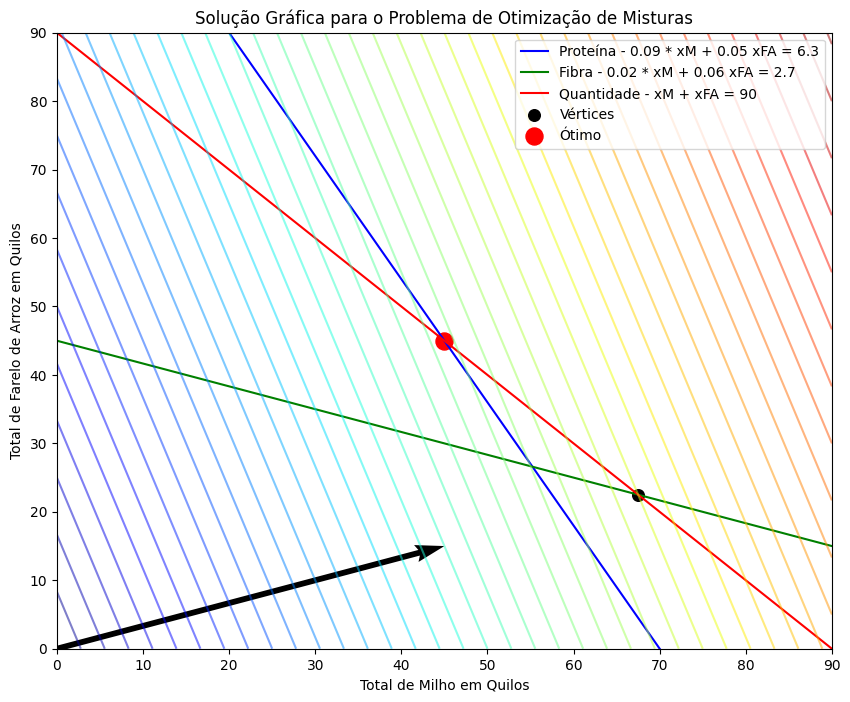

In [8]:
# Modelo 

x_M_max = 90
x_FA_max = 90

x_M = np.linspace(0, x_M_max, 25)
x_FA = np.linspace(0, x_FA_max, 25)

# Restrições

x_FA_proteina = (6.3 - 0.09 * x_M) / 0.05
x_FA_fibra = (2.7 - 0.02 * x_M) / 0.06
x_FA_quantidade = 90 - x_M



plt.figure(figsize=(10, 8))
plt.plot(x_M, x_FA_proteina, color='b',label = 'Proteína - 0.09 * xM + 0.05 xFA = 6.3')
plt.plot(x_M, x_FA_fibra, color='g',label = 'Fibra - 0.02 * xM + 0.06 xFA = 2.7')
plt.plot(x_M, x_FA_quantidade, color='r',label = 'Quantidade - xM + xFA = 90')

# Vertices do Modelo
# Sistema 1: Quantidade + Proteína
A1 = np.array([
    [1, 1],
    [0.09, 0.05]
])

b1 = np.array([90, 6.3])

v1 = np.linalg.solve(A1, b1)


# Sistema 2: Quantidade + Fibra
A2 = np.array([
    [1, 1],
    [0.02, 0.06]
])

b2 = np.array([90, 2.7])

v2 = np.linalg.solve(A2, b2)

vertices = np.array([v1, v2])
plt.scatter(vertices[:,0], vertices[:,1], label='Vértices',color='black',s=70)
Z = 0.9 * vertices[:,0] + 0.3 * vertices[:,1]
vertices[np.argmin(Z)]
plt.scatter(vertices[np.argmin(Z)][0], vertices[np.argmin(Z)][1], label='Ótimo',color='Red',s=150)



# Curvas de Nível
X, Y = np.meshgrid(x_M,x_FA)
Z = 0.9*X + 0.3*Y
plt.contour(X, Y, Z, 50, alpha=0.5, cmap='jet')

# Gradiente da função
c1, c2 = 0.9 * 50, 0.3 * 50
x0, y0 = 0,0

plt.quiver(x0, y0, c1, c2, angles='xy', scale_units='xy', scale=1)

plt.xlim(0, 90)
plt.ylim(0, 90)
plt.xlabel('Total de Milho em Quilos')
plt.ylabel('Total de Farelo de Arroz em Quilos')
plt.legend()
plt.title('Solução Gráfica para o Problema de Otimização de Misturas')
plt.show()


## Exercício 4
**Planejamento da Produção**

Durante os próximos seis meses, o Artesanato Itaipava Ltda. deve atender aos seguintes compromissos de sua seção de malharia:

* **Jan.** 4000 peças
* **Fev.** 2000 peças
* **Mar.** 5000 peças
* **Abr.** 1000 peças
* **Mai.** 4000 peças
* **Jun.** 2000 peças

Ao final de dezembro, há 500 peças em estoque e a empresa só tem capacidade para produzir 3000 peças mensais. Entretanto, usando horas extras, a empresa pode produzir até 600 peças a mais que sua capacidade nominal.

O custo variável de produzir uma peça é de $3 por peça, e o custo de produzir em horas extras é de $3,40 por peça. Além disso, peças que ficam em estoque de um mês para outro provocam um custo aproximado de $0,25 por peça.

Pede-se um modelo de Programação Linear que satisfaça a demanda, mas minimizando os custos de produção.

---

### Dados

In [9]:
dados = {
    'Mes':['Jan','Fev','Mar','Abr','Mai','Jun'],
    'Demanda': [4000,2000,5000,1000,4000,2000],
    'Estoque_Anterior': [500,0,0,0,0,0]
}

dados = pd.DataFrame(dados)
dados

,Mes,Demanda,Estoque_Anterior
0,Jan,4000,500
1,Fev,2000,0
2,Mar,5000,0
3,Abr,1000,0
4,Mai,4000,0
5,Jun,2000,0


### Modelo

#### Variáveis de Decisão

Quantidade a ser produzida em hora Normal no mês i:
$$
x_i, i= 1,2,3,4,5,6
$$
Quantidade a ser produzida em hora extra no mês i:
$$
y_i, i= 1,2,3,4,5,6
$$
Quantidade em estoque ao final do mês i:
$$
e_i, i= 1,2,3,4,5,6
$$


#### Função Objetivo

$$
Min Z = \sum_{i=1...6} 3 * x_i + 3,40 * y_i + 0,25 * e_i
$$

#### Restrições 

* Qtde Mensal (Hora Normal) - $x_i <= 3000$

* Qtde Mensal (Hora Extra) - $x_i <= 600$

* Produção do mês do mês (Demanda do mês = $d_i$) -  $e_{i-1} + x_i + y_i = d_i + e_i$

* Não Negatividade - $x_i >= 0$

In [10]:
def restricao_producao(modelo, mes):
    if mes == modelo.meses.first():
        return modelo.qtde_produzida_Estoque[mes] == (
            modelo.qtde_produzida_HoraNormal[mes]
            + modelo.qtde_produzida_HoraExtra[mes]
            + modelo.estoque_inicial +
            - modelo.demanda_mes[mes]
        )
    else:
        return modelo.qtde_produzida_Estoque[mes] == (
            modelo.qtde_produzida_HoraNormal[mes]
            + modelo.qtde_produzida_HoraExtra[mes]
            + modelo.qtde_produzida_Estoque[modelo.meses.prev(mes)]
            - modelo.demanda_mes[mes]
        )

# Dados
meses = dados['Mes'].to_list()
demanda = dados.set_index('Mes')['Demanda'].to_dict()

# Criacao do modelo

modelo = pyo.ConcreteModel()
modelo.meses = pyo.Set(initialize = meses)
modelo.demanda_mes = pyo.Param(modelo.meses, initialize=demanda)
modelo.estoque_inicial = pyo.Param(initialize=500)



# Variáveis de decisao 

modelo.qtde_produzida_HoraNormal = pyo.Var(modelo.meses,domain=pyo.NonNegativeReals)
modelo.qtde_produzida_HoraExtra = pyo.Var(modelo.meses,domain=pyo.NonNegativeReals)
modelo.qtde_produzida_Estoque = pyo.Var(modelo.meses,domain=pyo.NonNegativeReals)



# Função Objetivo

modelo.custo = pyo.Objective(expr= sum(3 * modelo.qtde_produzida_HoraNormal[mes] + 3.40 * modelo.qtde_produzida_HoraExtra[mes] + 0.25 * modelo.qtde_produzida_Estoque[mes] for mes in meses), sense=pyo.minimize)

# Sujeito as seguintes restrições

modelo.restricao_qtde_prod_HN = pyo.Constraint(meses, rule= lambda modelo, mes: modelo.qtde_produzida_HoraNormal[mes] <= 3000)
modelo.restricao_qtde_prod_HE = pyo.Constraint(meses, rule= lambda modelo, mes: modelo.qtde_produzida_HoraExtra[mes] <= 600)
modelo.producao = pyo.Constraint(modelo.meses, rule = restricao_producao)


# Solver 

solver = pyo.SolverFactory('glpk')
resultado = solver.solve(modelo, tee=False)

resultado = {
    'Mes': [],
    'Quantidade Produzida em Hora Normal': [],
    'Quantidade Produzida em Hora Extra':[],
    'Estoque do Mes':[]
}


for mes in modelo.meses:
    resultado['Mes'].append(mes)
    resultado['Quantidade Produzida em Hora Normal'].append(pyo.value(modelo.qtde_produzida_HoraNormal[mes]))
    resultado['Quantidade Produzida em Hora Extra'].append(pyo.value(modelo.qtde_produzida_HoraExtra[mes]))
    resultado['Estoque do Mes'].append(pyo.value(modelo.qtde_produzida_Estoque[mes]))
    
resultado = pd.DataFrame(resultado)

print(f"Custo total: R$ {pyo.value(modelo.custo):.2f}")
display(resultado)

Custo total: R$ 53700.00


,Mes,Quantidade Produzida em Hora Normal,Quantidade Produzida em Hora Extra,Estoque do Mes
0,Jan,3000.0,500.0,0.0
1,Fev,3000.0,400.0,1400.0
2,Mar,3000.0,600.0,0.0
3,Abr,2000.0,0.0,1000.0
4,Mai,3000.0,0.0,0.0
5,Jun,2000.0,0.0,0.0


## Exercício 5
**Processos Químicos**

A empresa Petro dispõe de duas fontes de petróleo bruto, denominadas Óleo A e Óleo B, vendidos em barris (bbl), que ela pode adquirir para processamento. O óleo A custa $28,00/bbl e o óleo B, $22,00/bbl; as quantidades disponíveis são de 10.000 bbl/dia e 7000 bbl/dia, respectivamente. 

Esses óleos podem passar por dois processos sucessivos, nos quais não há perdas em volume: primeiro uma destilação que agrupa os óleos em suas frações leves e pesadas, as quais podem ser vendidas ou processadas novamente. O segundo processo é um craqueamento que os transforma em dois produtos finais: gasolina e diesel.  As Tabelas 1.3a e 1.3b indicam as proporções resultantes dos dois processos. 

**TABELA 1.3a** % das frações por tipo de óleo 

| Tipo de óleo | Frações leves | Frações pesadas |
| :--- | :---: | :---: |
| Óleo A | 25% | 75% |
| Óleo B | 78% | 22% |

**TABELA 1.3b** % de gasolina e diesel por fração 

| Tipo de fração | Gasolina | Diesel |
| :--- | :---: | :---: |
| Frações leves | 80% | 20% |
| Frações pesadas | 35% | 65% |

Sabe-se que as frações leves podem ser vendidas a $20/bbl e as pesadas, por $27/bbl;  a gasolina é vendida por $35/bbl, enquanto o diesel é vendido a $30/bbl. 

---

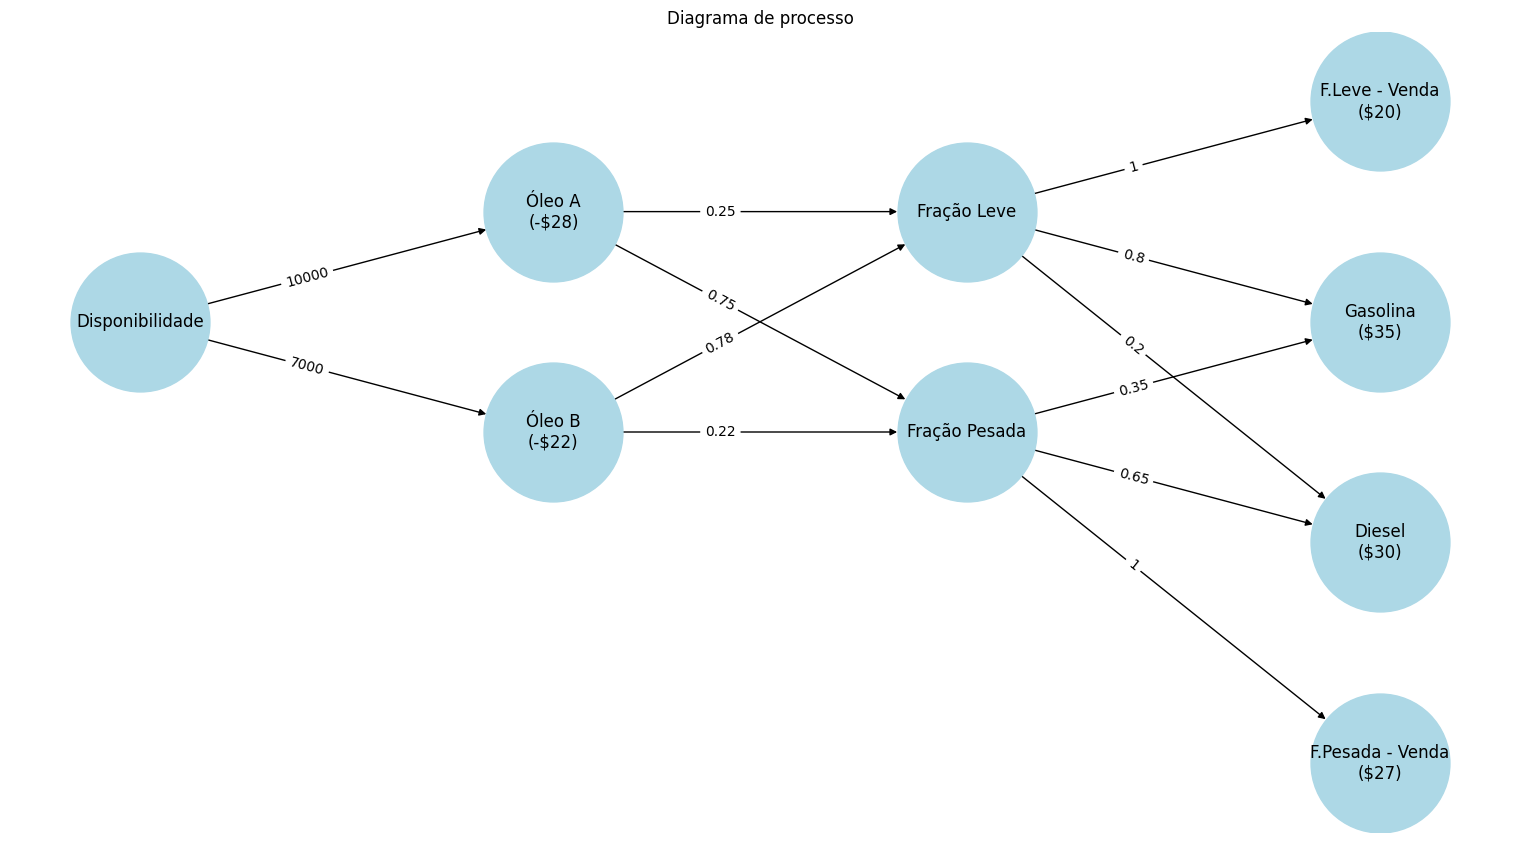

In [11]:
plt.figure(figsize=(15,8))
G = nx.DiGraph()

G.add_node("Disponibilidade")

G.add_node("Óleo A", custo=28)
G.add_node("Óleo B", custo=22)

G.add_node("Fração Leve")
G.add_node("Fração Pesada")

G.add_node("F.Leve - Venda", preco=20)
G.add_node("F.Pesada - Venda", preco=27)

G.add_node("Gasolina", preco=35)
G.add_node("Diesel", preco=30)

G.add_edge("Disponibilidade","Óleo A", proporcao=10000)
G.add_edge("Disponibilidade","Óleo B", proporcao=7000)

G.add_edge("Óleo A", "Fração Leve", proporcao=0.25)
G.add_edge("Óleo A", "Fração Pesada", proporcao=0.75)

G.add_edge("Óleo B", "Fração Leve", proporcao=0.78)
G.add_edge("Óleo B", "Fração Pesada", proporcao=0.22)

G.add_edge("Fração Leve", "F.Leve - Venda", proporcao=1)
G.add_edge("Fração Leve", "Gasolina", proporcao=0.80)
G.add_edge("Fração Leve", "Diesel", proporcao=0.20)

G.add_edge("Fração Pesada", "F.Pesada - Venda", proporcao=1)
G.add_edge("Fração Pesada", "Gasolina", proporcao=0.35)
G.add_edge("Fração Pesada", "Diesel", proporcao=0.65)

pos = {
    "Disponibilidade": (0,0),
    "Óleo A": (2, 1),
    "Óleo B": (2, -1),
    "Fração Leve": (4, 1),
    "Fração Pesada": (4, -1),
    "F.Leve - Venda": (6, 2),
    "Gasolina": (6, 0),
    "Diesel": (6, -2),
    "F.Pesada - Venda": (6, -4),
}

node_labels = {}

for node, data in G.nodes(data=True):
    if "preco" in data:
        node_labels[node] = f"{node}\n(${data['preco']})"
    elif "custo" in data:
        node_labels[node] = f"{node}\n(-${data['custo']})"
    else:
        node_labels[node] = node
        
nx.draw(G, pos, labels=node_labels, node_size=10000, node_color="lightblue")

edge_labels = nx.get_edge_attributes(G, 'proporcao')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, label_pos=0.4)

plt.title('Diagrama de processo')
plt.show()

### Dados

In [ ]:
oleos = pd.DataFrame({
    "oleo": ["A", "B"],
    "custo_bbl": [28, 22],
    "disponibilidade_bbl_dia": [10000, 7000]
})

destilacao = pd.DataFrame({
    "oleo": ["A", "A", "B", "B"],
    "fracao": ["leve", "pesada", "leve", "pesada"],
    "proporcao": [0.25, 0.75, 0.78, 0.22]
})

craqueamento = pd.DataFrame({
    "fracao": ["leve", "leve", "pesada", "pesada"],
    "produto": ["gasolina", "diesel", "gasolina", "diesel"],
    "proporcao": [0.80, 0.20, 0.35, 0.65]
})

precos = pd.DataFrame({
    "produto": ["leve", "pesada", "gasolina", "diesel"],
    "preco_bbl": [20, 27, 35, 30]
})

### Modelo

#### Variáveis de Decisão

Quantidade de Óleo i a ser comprada: $O_i, i= A,B$

Quantidade  de F. Leve Craqueada (Transformada em Gasolina ou Diesel): $L_C$

Quantidade  de F. Leve Vendida: $L_V$

Quantidade  de F. Pesada Craqueada (Transformada em Gasolina ou Diesel): $P_C$

Quantidade  de F. Pesada Vendida: $P_V$

Quantidade  de Gasolina a ser produzida: $G$

Quantidade  de Diesel a ser produzido: $D$



#### Função Objetivo

$$
Max Z = 20 * L_V + 27 * P_V + 35 * G + 30 * D - 28 * O_A - 22 * O_B
$$

#### Restrições 

* $L_V + L_C = 0,25 * O_A + 0,78 * O_B$

* $P_V + P_C = 0,75 * O_A + 0,22 * O_B$

* $G = 0,8 * L_C + 0,35 * P_C$

* $D = 0,2 * L_C + 0,65 * P_C$

* $O_A <= 10000$

* $O_B <= 7000$

* Não Negatividade - $O_i,L_C,L_V,...,D >= 0$

In [81]:
import pyomo.environ as pyo

modelo = pyo.ConcreteModel()

# Sets

modelo.OLEOS = pyo.Set(initialize=oleos["oleo"].tolist())
modelo.FRACOES = pyo.Set(initialize=destilacao["fracao"].unique().tolist())

# Produtos finais
produtos_finais = craqueamento["produto"].unique().tolist()
modelo.PRODUTOS = pyo.Set(initialize=produtos_finais)

# Parâmetros

# Custo óleo
modelo.custo = pyo.Param(
    modelo.OLEOS,
    initialize=oleos.set_index("oleo")["custo_bbl"].to_dict()
)

# Disponibilidade
modelo.disp = pyo.Param(
    modelo.OLEOS,
    initialize=oleos.set_index("oleo")["disponibilidade_bbl_dia"].to_dict()
)

# Destilação (óleo -> fração)
modelo.dest = pyo.Param(
    modelo.OLEOS,
    modelo.FRACOES,
    initialize={
        (row.oleo, row.fracao): row.proporcao
        for _, row in destilacao.iterrows()
    },
    default=0
)

# Craqueamento (fração -> produto)
modelo.craq = pyo.Param(
    modelo.FRACOES,
    modelo.PRODUTOS,
    initialize={
        (row.fracao, row.produto): row.proporcao
        for _, row in craqueamento.iterrows()
    },
    default=0
)

# Preços
preco_dict = precos.set_index("produto")["preco_bbl"].to_dict()

modelo.preco_prod = pyo.Param(
    modelo.PRODUTOS,
    initialize={p: preco_dict[p] for p in modelo.PRODUTOS}
)

modelo.preco_frac = pyo.Param(
    modelo.FRACOES,
    initialize={f: preco_dict[f] for f in modelo.FRACOES}
)

# Variáveis

# Óleo comprado
modelo.O = pyo.Var(modelo.OLEOS, domain=pyo.NonNegativeReals)

# Frações
modelo.VENDA = pyo.Var(modelo.FRACOES, domain=pyo.NonNegativeReals)
modelo.CRAQ = pyo.Var(modelo.FRACOES, domain=pyo.NonNegativeReals)

# Produtos finais
modelo.prod = pyo.Var(modelo.PRODUTOS, domain=pyo.NonNegativeReals)

# Função Objetivo

def obj_rule(modelo):
    receita = (
        sum(modelo.preco_prod[p] * modelo.prod[p] for p in modelo.PRODUTOS)
        + sum(modelo.preco_frac[f] * modelo.VENDA[f] for f in modelo.FRACOES)
    )
    
    custo = sum(modelo.custo[o] * modelo.O[o] for o in modelo.OLEOS)
    
    return receita - custo

modelo.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

# Restrições

# 1. Balanço de frações (DESTILAÇÃO)
def balanco_fracao(modelo, f):
    return (
        modelo.VENDA[f] + modelo.CRAQ[f]
        ==
        sum(modelo.dest[o, f] * modelo.O[o] for o in modelo.OLEOS)
    )

modelo.balanco = pyo.Constraint(modelo.FRACOES, rule=balanco_fracao)

# 2. Produção de produtos (CRAQUEAMENTO)
def producao(modelo, p):
    return modelo.prod[p] == sum(
        modelo.craq[f, p] * modelo.CRAQ[f]
        for f in modelo.FRACOES
    )

modelo.producao = pyo.Constraint(modelo.PRODUTOS, rule=producao)

# 3. Disponibilidade de óleo
def disp_rule(modelo, o):
    return modelo.O[o] <= modelo.disp[o]

modelo.disponibilidade = pyo.Constraint(modelo.OLEOS, rule=disp_rule)

# Solver

solver = pyo.SolverFactory("glpk")
resultado = solver.solve(modelo)

# Resultados

print("\nÓleo comprado:")
for o in modelo.OLEOS:
    print(o, pyo.value(modelo.O[o]))

print("\nVenda de frações:")
for f in modelo.FRACOES:
    print(f, pyo.value(modelo.VENDA[f]))

print("\nFrações craqueadas:")
for f in modelo.FRACOES:
    print(f, pyo.value(modelo.CRAQ[f]))

print("\nProdutos finais:")
for p in modelo.PRODUTOS:
    print(p, pyo.value(modelo.prod[p]))

print("\nLucro:", pyo.value(modelo.obj))


Óleo comprado:
A 10000.0
B 7000.0

Venda de frações:
leve 0.0
pesada 0.0

Frações craqueadas:
leve 7960.0
pesada 9040.0

Produtos finais:
gasolina 9532.0
diesel 7468.0

Lucro: 123660.0
